<a href="https://colab.research.google.com/github/AzraNA24/Deforestration-Drivers-Classification/blob/main/Tes_Area_and_NDVI_East_Kalimantan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inisialisasi**
---

## Import Earth Engine

In [1]:
import ee
ee.Authenticate()
ee.Initialize(project='deforestation-drivers-508922')

/usr/local/lib/python3.13/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(
*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_DIR = '/content/drive/MyDrive/skripsi_data'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(f'{DATA_DIR}/patches', exist_ok=True)
os.makedirs(f'{DATA_DIR}/rasters', exist_ok=True)
os.makedirs(f'{DATA_DIR}/tables',  exist_ok=True)
os.makedirs(f'{DATA_DIR}/maps',    exist_ok=True)
os.makedirs(f'{DATA_DIR}/anim',    exist_ok=True)
print("Struktur folder:")
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    print('  '*level + os.path.basename(root) + '/')

Mounted at /content/drive
Struktur folder:
skripsi_data/
  patches/
  rasters/
  tables/
  maps/
  anim/


## Ambil Area

In [3]:
provinces = ee.FeatureCollection('FAO/GAUL/2015/level1')
kaltim = provinces.filter(ee.Filter.eq('ADM1_NAME', 'Kalimantan Timur'))
aoi = kaltim.geometry()

/usr/local/lib/python3.13/dist-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for FAO/GAUL/2015/level1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by FAO/GAUL/2025/level1

Learn more: https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level1

  warnings.warn(warning, category=DeprecationWarning)


### Pengecekan Area yang Diambil

In [4]:
processed = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filterBounds(aoi)
              .filterDate('2020-01-01', '2025-12-31')
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

In [5]:
print('Jumlah citra 2020:', processed.filterDate('2020-01-01', '2020-12-31').size().getInfo())
print('Jumlah citra 2025:', processed.filterDate('2025-01-01', '2025-12-31').size().getInfo())

/usr/local/lib/python3.13/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


Jumlah citra 2020: 247
Jumlah citra 2025: 112


Nah, dari sini, karna di 2025 citranya jauh lebih sedikit, saya mau melihat range inputnya,

In [6]:
dates = processed.filterDate('2025-01-01', '2025-12-31').aggregate_array('system:time_start')
dates_list = dates.getInfo()
import datetime
print('Tanggal citra paling awal:', datetime.datetime.fromtimestamp(min(dates_list)/1000))
print('Tanggal citra paling akhir:', datetime.datetime.fromtimestamp(max(dates_list)/1000))

Tanggal citra paling awal: 2025-01-06 02:36:40.065000
Tanggal citra paling akhir: 2025-12-19 02:37:50.699000


Karna di kedua tahun data terakhir muncul di Desember, itu berarti citra yang rendah mungkin karna tutupan awannya. Harusnya nggak massalah. Tapi untuk klarifikasi lebih jauh, saya melihat citra perbulan.

In [7]:
import pandas as pd

dates_list = processed.filterDate('2025-01-01', '2025-12-31').aggregate_array('system:time_start').getInfo()
months = [datetime.datetime.fromtimestamp(d/1000).month for d in dates_list]
print(pd.Series(months).value_counts().sort_index())

1      1
3      5
5     27
6     14
7     28
8      6
9     11
10     6
11     6
12     8
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


Kode ini nunjukin seberapa banyak citra yang muncul dalam satu bulan.

Dapat dilihat bahwa citra banyak diambil pada rentang Mei-Juni yang bisa diklasifikasikan sebagai Kemarau.

Hal ini berarti composite berikut secara efektif "condong" merepresentasikan musim kemarau saja, yang bisa membuat bias sistematis dibanding composite 2020 yang mungkin terdistribusi lebih merata sepanjang tahun. Jadi, kita lakukan sedikit perbandingan.

### Visualisasi Distribusi Citra

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

**Ambil Citra Perbulan**

In [9]:
def get_monthly_counts(processed, year):
    start = f'{year}-01-01'
    end   = f'{year}-12-31'

    timestamps = (processed
                  .filterDate(start, end)
                  .aggregate_array('system:time_start')
                  .getInfo())

    if not timestamps:
        return pd.Series(0, index=range(1, 13), name=year)

    months = [datetime.fromtimestamp(d / 1000).month for d in timestamps]
    counts = pd.Series(months).value_counts().sort_index()

    counts = counts.reindex(range(1, 13), fill_value=0)
    counts.name = year
    return counts

In [10]:
years = [2020, 2021, 2022, 2023, 2024, 2025]
df = pd.DataFrame({y: get_monthly_counts(processed, y) for y in years})
df.index = ['Jan','Feb','Mar','Apr','Mei','Jun',
            'Jul','Ags','Sep','Okt','Nov','Des']
df.index.name = 'Bulan'

print(df)
print("\nTotal per tahun:")
print(df.sum())

/usr/local/lib/python3.13/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


       2020  2021  2022  2023  2024  2025
Bulan                                    
Jan      31     0     4     1     5     1
Feb      30     6     7     1    46     0
Mar      32    13    12     5    10     5
Apr      35    15     4     2    26     0
Mei      22    41    12    13     6    27
Jun       2    44    11     8     1    14
Jul      35    23    25    24    16    28
Ags      23     9     9    23     3     6
Sep       6    10     7    24    27    11
Okt      12    11     0    33     3     6
Nov      16     4     0     2     4     6
Des       3     4     0     5     2     8

Total per tahun:
2020    247
2021    180
2022     91
2023    141
2024    149
2025    112
dtype: int64


In [11]:
dry_months = ['Mei','Jun','Jul','Ags']
wet_months = ['Nov','Des','Jan','Feb','Mar','Apr']

rekap = pd.DataFrame({
    'Total'      : df.sum(),
    'Kemarau'    : df.loc[dry_months].sum(),
    'Hujan'      : df.loc[wet_months].sum(),
})
rekap['% Kemarau'] = (rekap['Kemarau'] / rekap['Total'] * 100).round(1)
rekap['Rasio K:H'] = (rekap['Kemarau'] / rekap['Hujan']).round(2)

print(rekap)

      Total  Kemarau  Hujan  % Kemarau  Rasio K:H
2020    247       82    147       33.2       0.56
2021    180      117     42       65.0       2.79
2022     91       57     27       62.6       2.11
2023    141       68     16       48.2       4.25
2024    149       26     93       17.4       0.28
2025    112       75     20       67.0       3.75


In [12]:
df.to_csv(f'{DATA_DIR}/tables/distribusi_citra_bulanan_Kaltim.csv')

**Heatmap Bulan x Tahun**

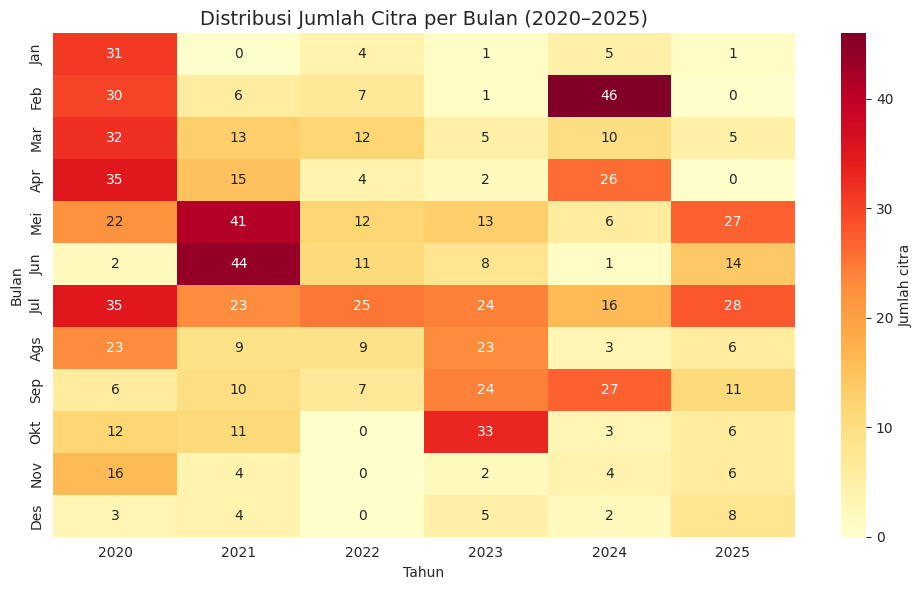

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Jumlah citra'})
plt.title('Distribusi Jumlah Citra per Bulan (2020–2025)', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Bulan')
plt.tight_layout()
plt.show()

Di sini terlihat Citra tidak memiliki kecenderungan

**Perbandingan Citra di Musim Kemarau**

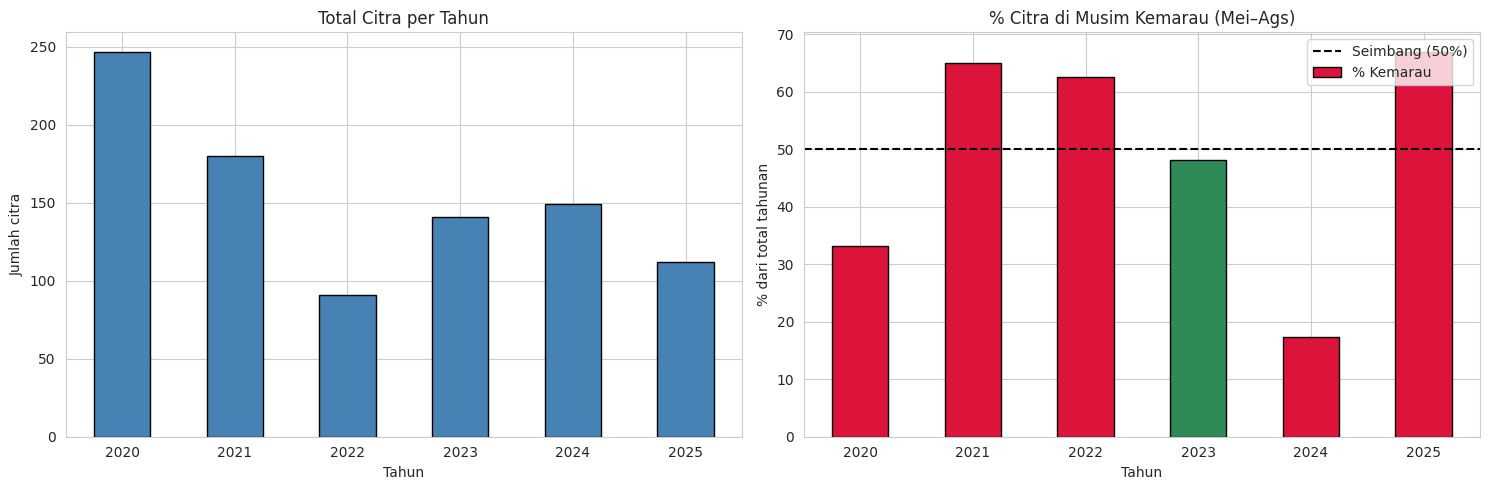

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel kiri: total citra
rekap['Total'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Citra per Tahun')
axes[0].set_ylabel('Jumlah citra')
axes[0].set_xlabel('Tahun')
axes[0].tick_params(axis='x', rotation=0)

# Panel kanan: % kemarau
colors = ['crimson' if v > 60 or v < 40 else 'seagreen'
          for v in rekap['% Kemarau']]
rekap['% Kemarau'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].axhline(50, color='black', linestyle='--', label='Seimbang (50%)')
axes[1].set_title('% Citra di Musim Kemarau (Mei–Ags)')
axes[1].set_ylabel('% dari total tahunan')
axes[1].set_xlabel('Tahun')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

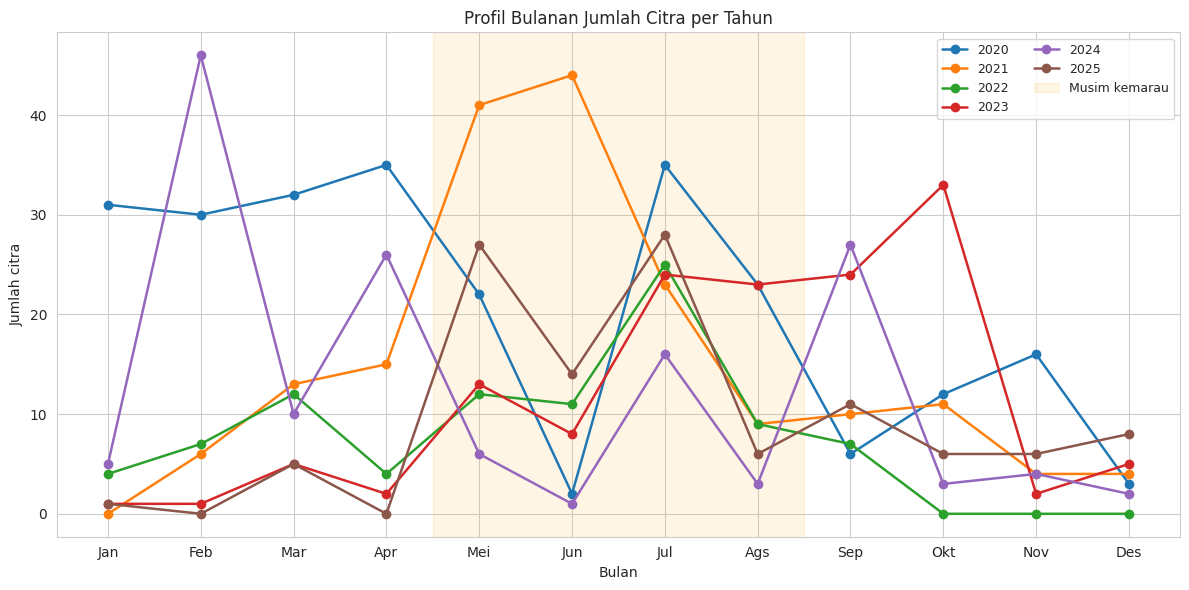

In [15]:
plt.figure(figsize=(12, 6))
for y in years:
    plt.plot(df.index, df[y], marker='o', label=str(y), linewidth=1.8)

plt.axvspan(3.5, 7.5, alpha=0.1, color='orange', label='Musim kemarau')
plt.title('Profil Bulanan Jumlah Citra per Tahun')
plt.xlabel('Bulan')
plt.ylabel('Jumlah citra')
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

**Lihat Outliernya**

In [16]:
vals = np.array([65, 49, 57, 49, 30, 73])
mean, std = vals.mean(), vals.std(ddof=0)
z = (vals - mean) / std
print("Mean:", round(mean,1), "Std:", round(std,1))
print ("Z-Score:", z)

Mean: 53.8 Std: 13.6
Z-Score: [ 0.8184742  -0.35426495  0.23210462 -0.35426495 -1.74689269  1.40484377]


In [17]:
from scipy import stats

z = np.abs(stats.zscore(rekap['% Kemarau']))
rekap['Z-score'] = z.round(2)
rekap['Outlier'] = np.where(z > 1.5, 'KanYe', 'KanNo')

print(rekap[['Total','% Kemarau','Rasio K:H','Z-score','Outlier']])

      Total  % Kemarau  Rasio K:H  Z-score Outlier
2020    247       33.2       0.56     0.86   KanNo
2021    180       65.0       2.79     0.88   KanNo
2022     91       62.6       2.11     0.75   KanNo
2023    141       48.2       4.25     0.04   KanNo
2024    149       17.4       0.28     1.72   KanYe
2025    112       67.0       3.75     0.99   KanNo


Bisa dilihat bahwa 2024 adalah outlier di sini.
Sedang 2025, walau secara visualisasi ia merupakan outlier, ia lolos Z-score.

Hal ini disebabkan threshold tunggal rapuh di n kecil (6 tahun).

Tapi di luar itu, kita bisa flagging composite bias di Musim kemarau. Hal ini bisa didasari beberapa hal;
1. Faktor fisik   
Pada musim kemarau, tutupan awan lebih rendah, sehingga lebih banyak citra yang lolos filter kualitas, sedang  pada musim hujan, awan tebal, sehingga banyak yang terbuang

2. Faktor Kesediaan Akusisi  
Jumlah scene mentah perbulan relatif konstan (Sentinel-2 ~10/hari) namun dikarnakan data yang diambil adalah 2A, hasil citra ini adalah yang tersisa setelah cloud masking.



### NDVI dan Mask Cloud

In [18]:
def mask_clouds(image):
    scl = image.select('SCL')
    # SCL class 3 = cloud shadow, 8-10 = cloud (medium/high prob + cirrus), 11 = snow
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
    return image.updateMask(mask)

def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

In [19]:
collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate('2020-01-01', '2025-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_clouds)
    .map(add_ndvi))

In [20]:
composite_2020 = collection.filterDate('2020-01-01', '2020-12-31').median().clip(aoi)
ndvi_2020 = composite_2020.select('NDVI')

composite_2025 = collection.filterDate('2025-01-01', '2025-12-31').median().clip(aoi)
ndvi_2025 = composite_2025.select('NDVI')

## Deteksi Perubahan (NDVI)

In [21]:
def classify_ndvi(ndvi_image):
    """
    Klasifikasi kerapatan vegetasi (Al-Doski dkk., 2013):
      1 = Non-vegetasi     : -1  ≤ NDVI < 0.2
      2 = Vegetasi jarang  :  0.2 ≤ NDVI < 0.4
      3 = Vegetasi sedang  :  0.4 ≤ NDVI < 0.6
      4 = Vegetasi rapat   :  0.6 ≤ NDVI ≤ 1
    """
    return (ndvi_image
        .expression(
            "(b('NDVI') < 0.2) ? 1"
            ": (b('NDVI') < 0.4) ? 2"
            ": (b('NDVI') < 0.6) ? 3"
            ": 4"
        )
        .rename('NDVI_class')
        .byte())

### Meminimalisir Bias

Melihat pebandingan citra, untuk menghindari bias musim, kesemua data diambil di musim kemarau saja.

In [22]:
years = [2020, 2021, 2022, 2023, 2024, 2025]
ndvi_yearly = {}
class_yearly = {}

for y in years:
    comp = (collection
            .filterDate(f'{y}-02-01', f'{y}-10-30')
            .median()
            .clip(aoi))
    ndvi_yearly[y]  = comp.select('NDVI')
    class_yearly[y] = classify_ndvi(comp.select('NDVI'))

### Visualisai Peta Kerapatan Vegetasi 2020-2025

In [23]:
import geemap
maps = []
for y in years:
    m = geemap.Map(center=[-1.5, 113], zoom=7)
    vis_class = {'min': 1, 'max': 4, 'palette': ['#d7191c', '#fdae61', '#a6d96a', '#1a9850']}
    m.addLayer(class_yearly[y], vis_class, f'Klasifikasi {y}')
    m.addLayer(aoi, {'color': 'black'}, 'Batas')
    m.add_legend(
        title=f'Kerapatan Vegetasi {y}',
        legend_dict={
            'Non-vegetasi'   : '#d7191c',
            'Vegetasi jarang': '#fdae61',
            'Vegetasi sedang': '#a6d96a',
            'Vegetasi rapat' : '#1a9850',
        })
    maps.append(m)

for m in maps:
    display(m)

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Map(center=[-1.5, 113], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

### Analisis Luas per Kelas

In [24]:
def area_by_class(class_image, year=None):
    class_image = class_image.select('NDVI_class')

    # Band area dalam hektar
    area_ha = ee.Image.pixelArea().divide(1e4).rename('area')
    stack = area_ha.addBands(class_image.rename('class_id'))

    stats = stack.reduceRegion(
        reducer=ee.Reducer.sum().group(
            groupField=1,
            groupName='class'),
        geometry=aoi,
        scale=20,
        maxPixels=1e13,
        bestEffort=True
    ).getInfo()

    label = {1:'Non-vegetasi', 2:'Vegetasi jarang',
             3:'Vegetasi sedang', 4:'Vegetasi rapat'}

    rows = {g['class']: g['sum'] for g in stats.get('groups', [])}
    # Isi kelas yang kosong dengan 0
    result = {label[k]: round(rows.get(k, 0), 2) for k in [1,2,3,4]}
    return result

df_area = pd.DataFrame({y: area_by_class(class_yearly[y], y)
                        for y in years}).T
df_area.index.name = 'Tahun'
print(df_area)

       Non-vegetasi  Vegetasi jarang  Vegetasi sedang  Vegetasi rapat
Tahun                                                                
2020      491706.76        474946.80       1221801.83     17540723.35
2021      519314.28        443178.33       1032538.78     17734147.35
2022      280379.68        186481.65        493564.84     18768752.58
2023      443164.18        249247.71        550558.47     18486208.39
2024      396050.62        258607.93        512582.28     18561937.92
2025      320354.09        203139.44        491209.72     18714475.50


In [25]:
df_area.to_csv(f'{DATA_DIR}/tables/luas_kerapatan_ndvi_Kaltim.csv')

### Rata-rata NDVI Spasial Per-Tahun

In [38]:
import datetime

years = list(range(2020, 2026))
ndvi_yearly_mean = []

for year in years:
    yearly_composite = (collection
        .filterDate(f'{year}-02-01', f'{year}-10-30')
        .median()
        .clip(aoi)
        .select('NDVI'))

    stats = yearly_composite.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=100,
        maxPixels=1e13
    )

    mean_val = stats.get('NDVI').getInfo()
    ndvi_yearly_mean.append(mean_val)
    print(f'{year}: {mean_val:.4f}')

2020: 0.7635
2021: 0.7569
2022: 0.8071
2023: 0.7864
2024: 0.7879
2025: 0.7990


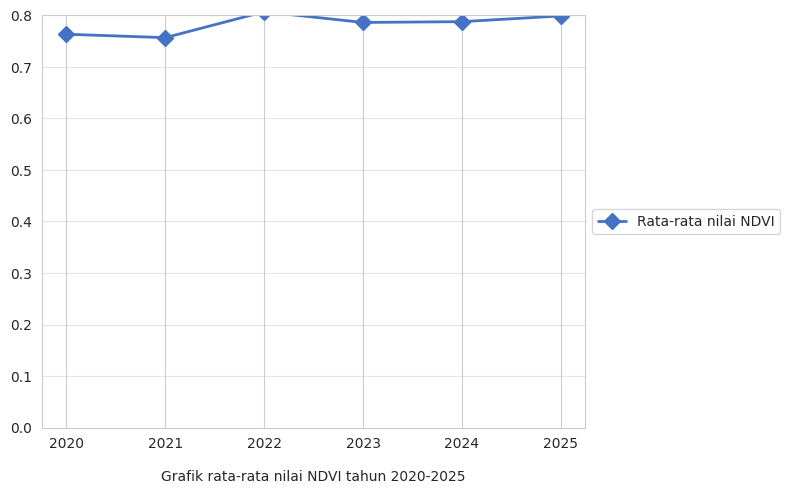

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(years, ndvi_yearly_mean, marker='D', color='#4472C4', linewidth=2, markersize=8, label='Rata-rata nilai NDVI')

plt.ylim(0, 0.8)
plt.yticks([i/10 for i in range(0, 9)])
plt.xticks(years)
plt.grid(axis='y', linestyle='-', alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title(f'Grafik rata-rata nilai NDVI tahun {years[0]}-{years[-1]}', y=-0.15, fontsize=10)

plt.tight_layout()
plt.savefig('ndvi_trend.png', dpi=300, bbox_inches='tight')
plt.show()

Angkanya masih tergolong sangat tinggi. Hal ini dikarnakan rata-rata ini dihitung untuk **seluruh provinsi Kalimantan Tengah (~15 juta hektar)**, yang mayoritas areanya adalah hutan primer/sekunder yang stabil dan tidak mengalami perubahan apa pun selama periode ini.

Walau kita dapat melihat perubahan vegetasi di peta, area yang benar-benar mengalami deforestasi (dari data Hansen, biasanya berupa titik/patch-patch kecil tersebar) itu secara proporsi luasnya sangat kecil dibanding total luas provinsi, jadi efeknya diluted dalam rata-rata keseluruhan. Perubahan lokal itu tidak akan terlihat di angka agregat sebesar itu.

## Deteksi Perubahan (GFC & NDVI)

In [40]:
hansen = ee.Image('UMD/hansen/global_forest_change_2025_v1_13')
lossyear = hansen.select('lossyear').clip(aoi)

# filter hanya loss yang terjadi DALAM periode studi (2020-2025)
# lossyear 20 = 2020, lossyear 25 = 2025
loss_in_window = lossyear.gte(20).And(lossyear.lte(25))

# cek dulu berapa banyak piksel yang benar-benar match
pixel_count = loss_in_window.selfMask().reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=aoi,
    scale=30,
    maxPixels=1e13
).getInfo()
print('Piksel loss dalam 2020-2025:', pixel_count)

# konversi piksel ke luas
area_ha = pixel_count['lossyear'] * (30 * 30) / 10000  # piksel × luas per piksel (m²) / 10000 (ke hektar)
print(f'Luas area loss 2020-2025: {area_ha:,.0f} hektar (~{area_ha/100:,.0f} km²)')

Piksel loss dalam 2020-2025: {'lossyear': 8885879}
Luas area loss 2020-2025: 799,729 hektar (~7,997 km²)


In [29]:
ndvi_yearly_mean_loss_area = []

for year in years:
    yearly_composite = (collection
        .filterDate(f'{year}-02-01', f'{year}-12-31')
        .median()
        .clip(aoi)
        .select('NDVI')
        .updateMask(loss_in_window))

    stats = yearly_composite.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=30,
        maxPixels=1e13
    )

    mean_val = stats.get('NDVI').getInfo()
    ndvi_yearly_mean_loss_area.append(mean_val)
    print(f'{year}: {mean_val:.4f}')

2020: 0.7715
2021: 0.7594
2022: 0.7839
2023: 0.7204
2024: 0.6992
2025: 0.7066


Setelah dioverlay dengan data GFC, mulai terlihat penurunan NDVI yang ada.

Bisa dilihat pula  bahwa piksel lossnya mencapai 7.396.489 atau lebih dari 665.000 hektar.

### Analisis per-*cohort*

In [43]:
cohort_trends = {}

for cohort_year in years:
    lossyear_code = cohort_year - 2000
    cohort_mask = lossyear.eq(lossyear_code)

    trend = []
    for obs_year in years:
        comp = (collection
            .filterDate(f'{obs_year}-01-01', f'{obs_year}-10-30')
            .median().clip(aoi).select('NDVI')
            .updateMask(cohort_mask))
        val = comp.reduceRegion(ee.Reducer.mean(), aoi, 30, maxPixels=1e13).get('NDVI').getInfo()
        trend.append(val)

    cohort_trends[cohort_year] = trend
    print(f'Loss tahun {cohort_year}:', [f'{v:.3f}' if v else 'N/A' for v in trend])

Loss tahun 2020: ['0.612', '0.670', '0.761', '0.740', '0.741', '0.749']
Loss tahun 2021: ['0.801', '0.621', '0.700', '0.714', '0.731', '0.743']
Loss tahun 2022: ['0.804', '0.788', '0.622', '0.660', '0.685', '0.732']
Loss tahun 2023: ['0.797', '0.798', '0.818', '0.588', '0.594', '0.720']
Loss tahun 2024: ['0.798', '0.800', '0.838', '0.804', '0.649', '0.701']
Loss tahun 2025: ['0.808', '0.812', '0.839', '0.826', '0.822', '0.626']


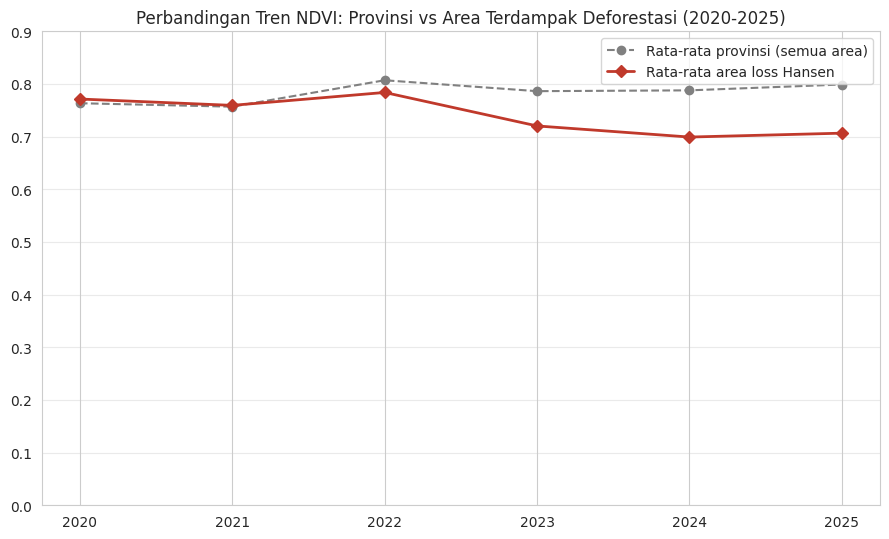

In [44]:
plt.figure(figsize=(9, 5.5))
plt.plot(years, ndvi_yearly_mean, marker='o', label='Rata-rata provinsi (semua area)', color='gray', linestyle='--')
plt.plot(years, ndvi_yearly_mean_loss_area, marker='D', label='Rata-rata area loss Hansen', color='#c0392b', linewidth=2)
plt.ylim(0, 0.9)
plt.xticks(years)
plt.grid(axis='y', alpha=0.4)
plt.legend()
plt.title('Perbandingan Tren NDVI: Provinsi vs Area Terdampak Deforestasi (2020-2025)')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/tables/perbandingan_ndvi_trend.png', dpi=300, bbox_inches='tight')
plt.show()

### Dokumentasi Lanjutan

**GeoTiff**

In [32]:
# EE_EXPORT_FOLDER = 'EE_Kalteng_NDVI'

# tasks = []
# for y in years:
#     t = ee.batch.Export.image.toDrive(
#         image=class_yearly[y].toByte(),
#         description=f'class_kalteng_{y}',
#         folder=EE_EXPORT_FOLDER,
#         fileNamePrefix=f'class_kalteng_{y}',
#         region=aoi, scale=20, maxPixels=1e13,
#         crs='EPSG:4326', fileFormat='GeoTIFF'
#     )
#     t.start()
#     tasks.append((y, t))
#     print(f'Export {y} dimulai.')

# # Ekspor peta perubahan
# change_map = (ee.Image(0)
#     .where(class_yearly[2020].eq(4).And(class_yearly[2025].eq(1)), 1)
#     .where(class_yearly[2020].gte(3).And(class_yearly[2025].lte(2)), 2)
#     .where(class_yearly[2020].lte(2).And(class_yearly[2025].gte(3)), 3)
#     .selfMask().rename('change').byte())

# ee.batch.Export.image.toDrive(
#     image=change_map, description='perubahan_kalteng_2020_2025',
#     folder=EE_EXPORT_FOLDER, fileNamePrefix='perubahan_kalteng_2020_2025',
#     region=aoi, scale=20, maxPixels=1e13, crs='EPSG:4326'
# ).start()
# print("Export peta perubahan dimulai.")

In [33]:
# import time, shutil, glob

# def wait_and_move(tasks, dest_dir, src_folder=EE_EXPORT_FOLDER,
#                   timeout_min=60):
#     src_path = f'/content/drive/MyDrive/{src_folder}'
#     os.makedirs(dest_dir, exist_ok=True)
#     t0 = time.time()
#     pending = list(tasks)

#     while pending and (time.time() - t0) < timeout_min*60:
#         still = []
#         for y, t in pending:
#             state = t.status()['state']
#             if state in ('COMPLETED','FAILED','CANCELLED'):
#                 print(f'  [{y}] {state}')
#             else:
#                 still.append((y, t))
#         pending = still
#         if pending:
#             time.sleep(20)

#     moved = []
#     for f in glob.glob(f'{src_path}/*.tif'):
#         base = os.path.basename(f)
#         target = os.path.join(dest_dir, base)
#         if not os.path.exists(target):
#             shutil.move(f, target)
#             moved.append(base)
#     print(f'Dipindahkan ke {dest_dir}:')
#     for m in moved: print('  -', m)
#     return moved

# wait_and_move(tasks, dest_dir=f'{DATA_DIR}/rasters')

**Peta PNG**

In [34]:
# import os
# import ee
# import geemap

# output_dir = f'{DATA_DIR}/maps'
# os.makedirs(output_dir, exist_ok=True)

# for y in years:

#     output_tif = f'{output_dir}/kerapatan_vegetasi_{y}.tif'

#     geemap.ee_export_image(
#         class_yearly[y].clip(aoi),
#         filename=output_tif,
#         scale=30,
#         region=aoi,
#         file_per_band=False
#     )

#     print(f'Tersimpan: {output_tif}')

In [35]:
# import matplotlib.pyplot as plt
# import rasterio
# from matplotlib.colors import ListedColormap
# import os

# cmap = ListedColormap([
#     '#d7191c',  # Non-vegetasi
#     '#fdae61',  # Vegetasi jarang
#     '#a6d96a',  # Vegetasi sedang
#     '#1a9850'   # Vegetasi rapat
# ])

# for y in years:

#     tif_file = f'{output_dir}/kerapatan_vegetasi_{y}.tif'
#     png_file = f'{output_dir}/kerapatan_vegetasi_{y}.png'

#     with rasterio.open(tif_file) as src:
#         data = src.read(1)

#     plt.figure(figsize=(10, 8))

#     plt.imshow(
#         data,
#         cmap=cmap,
#         vmin=1,
#         vmax=4
#     )

#     plt.title(f'Kerapatan Vegetasi {y}')
#     plt.axis('off')

#     # Legend
#     labels = [
#         'Non-vegetasi',
#         'Vegetasi jarang',
#         'Vegetasi sedang',
#         'Vegetasi rapat'
#     ]

#     from matplotlib.patches import Patch

#     legend_elements = [
#         Patch(facecolor='#d7191c', label='Non-vegetasi'),
#         Patch(facecolor='#fdae61', label='Vegetasi jarang'),
#         Patch(facecolor='#a6d96a', label='Vegetasi sedang'),
#         Patch(facecolor='#1a9850', label='Vegetasi rapat')
#     ]

#     plt.legend(
#         handles=legend_elements,
#         loc='lower right'
#     )

#     plt.savefig(
#         png_file,
#         dpi=300,
#         bbox_inches='tight'
#     )

#     plt.close()

#     print(f'Tersimpan: {png_file}')

**Gif**

In [36]:
!pip install mss

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 2.5 MB/s eta 0:00:00


In [37]:
# frames = []
# for y in years:
#     img = fetch_tile(get_tile_url(class_yearly[y], vis_class), bbox_kalteng)
#     frames.append(np.array(img.convert('RGB')))

# gif_path = f'{DATA_DIR}/anim/kerapatan_kalteng_2020_2025.gif'
# imageio.mimsave(gif_path, frames, duration=1.2, loop=0)
# print(f"Tersimpan: {gif_path}")

### **RUSAKRUSAKRUSAKRUSAKRUSAKRUSAKRUSAKRUSAKRUSAKRUSAKRUSAK**